#### Geophysics Project

In [25]:
import numpy as np 
import obspy
import matplotlib.pyplot as plt
import os,glob

Create an inventory of stations located in Greenland using min/max latitude-longitude box. However, it includes stations from Iceland and N Canada.

In [ ]:
from obspy.clients.fdsn import Client

client = Client("IRIS")
inv=client.get_stations(minlatitude=59.50, maxlatitude=83.80, 
                        minlongitude=-73.50, maxlongitude=-11.00,
                        network='*',channel='?H?',
                        level='channel')

Filter stations to those located in Greenland.

In [7]:
import geopandas as gpd
from shapely.geometry import Point

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_0_countries.geojson"
world_countries = gpd.read_file(url)

greenland_polygon = world_countries[world_countries["NAME"] == "Greenland"].geometry.values

greenland_buffered = greenland_polygon.buffer(0.35)

inventory = inv.copy() # Copy the inv for filtering

not_greenland_networks = []
for network in inventory:

    greenland_stations = []
    for station in network:
        coord = Point(station.longitude, station.latitude)
        if greenland_polygon.contains(coord):
            greenland_stations.append(station)
    network.stations = greenland_stations
    
    if len(greenland_stations) == 0:
        not_greenland_networks.append(network)
for n in not_greenland_networks: 
    inventory.networks.remove(n)    

print(inventory) 

c:\Users\sella\miniconda3\envs\2nd_year_project\Lib\site-packages\IPython\core\interactiveshell.py:3641: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  if await self.run_code(code, result, async_=asy):


Inventory created at 2026-08-28T21:23:09.288600Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?network=%2A&c...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (22):
			14, 5Q, 6H, 7E, 9C, 9D, DK, DW, G, GE, GG, IU, X3, XF, XW, Y6, YE, 
			YF, YM, YV, ZN, ZS
		Stations (125):
			14.ISR0 (Isunnguata Sermia Terminus)
			5Q.SE47 (Transect site, southern most, Ilulissat, Greenland)
			5Q.SE50 (Transect site, 2rd from south, Ilulissat, Greenland)
			5Q.SE53 (Transect site, 3rd from south, Ilulissat, Greenland)
			5Q.SE57 (Transect site, 4rd from south, Ilulissat, Greenland)
			5Q.SE60 (Transect site, 5rd from south, Ilulissat, Greenland)
			5Q.SE63 (Transect site, 6th from south, Ilulissat, Greenland)
			5Q.SEHC (Seismic site at MoVE high camp, Ilulissat, Greenland)
			5Q.SELC (Seismic site at MoVE low camp, Ilulissat, Greenland)
			6H.GL11 (GL11)
			6H.GL12 (GL12)
			6H.GL13 (GL13)
			6H

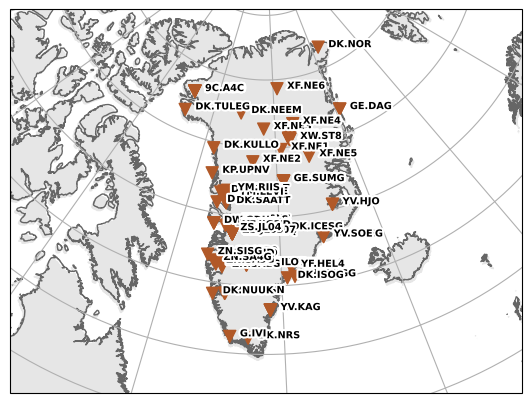

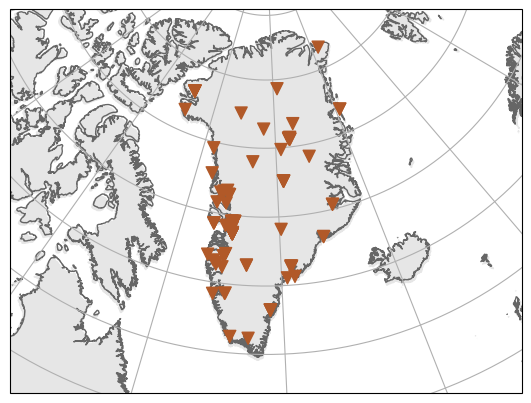

In [34]:
plt.rcParams['font.size'] = 7.0
fig_station_labeled = inventory.plot( projection="local", size=75.0, resolution="f", method="cartopy")

fig_station = inventory.plot( projection="local", size=75.0, label=False, resolution="f", method="cartopy")

plt.show()